# Detect output

In [1]:
#source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


## Use celldetect notebook to create files!

In [2]:
##jupyter nbconvert --to script celldetect.ipynb

In [3]:
bash celldetect.sh
##REGRESSION_TEST: bash $CIAOTEST_TESTS/threads/celldetect.MAIN


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       10 Mb  ####################          < 1 s  39107.4 kb/s
  bpix     fits       19 Kb    already downloaded
  fov      fits        6 Kb    already downloaded
  asol     fits        5 Mb    already downloaded
  flt      fits        7 Kb    already downloaded
  msk      fits        5 Kb    already downloaded
  pbk      fits        4 Kb    already downloaded

      Total download size for ObsId 578 = 10 Mb
      Total download time for ObsId 578 = < 1 s


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  evt2     fits       20 Mb    already downloaded
  bpix     fits       44 Kb    already downloaded
  fov      fits        6 Kb    already downloaded
  asol     fits       10 Mb    already downloaded
  flt    

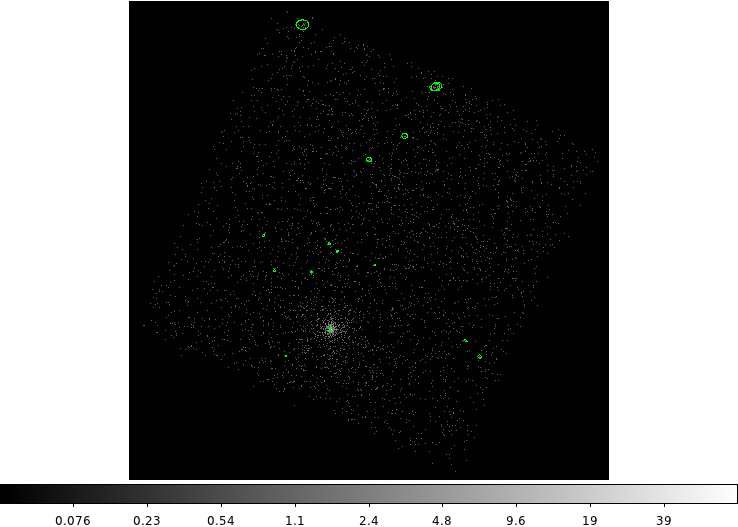

In [4]:
ds9 s3_broad_thresh.img -log -region s3_src.fits -zoom to fit -saveimage png ds9_1.png -quit
display < ds9_1.png

## Examing source list

In [5]:
dmlist s3_src.fits blocks

 
--------------------------------------------------------------------------------
Dataset: s3_src.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCLIST                        Table        31 cols x 17       rows


In [6]:
dmlist "s3_src.fits[cols RA,DEC,POS]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    RA                   DEC                  POS(X,Y)
 
     1       212.8639501188        52.1921273978 (     3961.7571428571,     4035.0714285714)
     2       212.8360726227        52.2021137798 (     4086.8032786885,     4108.1147540984)
     3       212.8353651758        52.2027847341 (     4089.9759036145,     4113.0240963855)
     4       212.8349227409        52.2031706722           (     4091.960,     4115.8480)
     5       212.8783563224        52.2399625097 (     3897.3529411765,     4385.1176470588)
     6       212.8712813825        52.2258301626       (     3929.0,     4281.6923076923)
     7       212.8474702799        52.2255288532 (     4035.7228381375,     4279.4501108647)
     8       212.8360692107        52.2365737442 (     4086.8260869565,     4360.2608695652)
     9 

## Manipulate


In [7]:
dmcopy "s3_src.fits[#row=1:11,13:15]" s3_1gone_src.fits cl+
dmlist s3_1gone_src.fits blocks

 
--------------------------------------------------------------------------------
Dataset: s3_1gone_src.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCLIST                        Table        31 cols x 14       rows


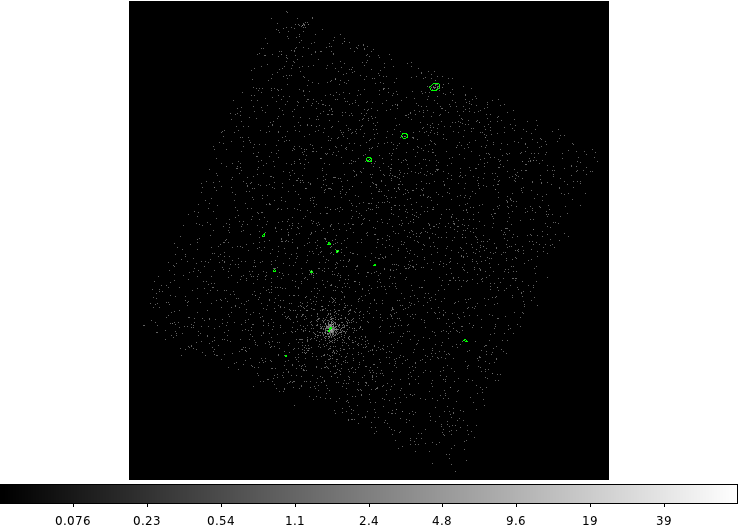

In [8]:
ds9 s3_broad_thresh.img -log -region s3_1gone_src.fits -zoom to fit -saveimage png ds9_2.png -quit
display < ds9_2.png

In [9]:
dmcopy "s3_src.fits[#row=1:7,9:11,13,15]" s3_3gone_src.fits clob+

dmlist s3_3gone_src.fits blocks


 
--------------------------------------------------------------------------------
Dataset: s3_3gone_src.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SRCLIST                        Table        31 cols x 12       rows


In [10]:
dmlist s3_3gone_src.fits"[cols ra,dec,net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    RA                   DEC                  NET_COUNTS
 
     1       212.8639501188        52.1921273978               63.250
     2       212.8360726227        52.2021137798             33.43750
     3       212.8353651758        52.2027847341             87.81250
     4       212.8349227409        52.2031706722              67.6250
     5       212.8783563224        52.2399625097        31.4285717010
     6       212.8712813825        52.2258301626        23.4285717010
     7       212.8474702799        52.2255288532       439.4285583496
     8       212.8309929845        52.2335243759       134.7142791748
     9       212.8067117410        52.2281085126        32.4285697937
    10       212.7481005259        52.1982204514        51.1428565979
    11       212.8103352862        52.26981

## Sort

In [11]:
dmlist "s3_src.fits[cols net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1               63.250
     2             33.43750
     3             87.81250
     4              67.6250
     5        31.4285717010
     6        23.4285717010
     7       439.4285583496
     8        20.4285717010
     9       134.7142791748
    10        32.4285697937
    11        51.1428565979
    12        32.2386360168
    13        27.8571434021
    14                 32.0
    15        60.2954559326
    16       108.2324981689
    17        79.1034469604


In [12]:
dmsort s3_src.fits s3_sorted_src.fits keys=net_counts copyall=yes cl+

dmlist "s3_sorted_src.fits[cols net_counts]" data
 

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1        20.4285717010
     2        23.4285717010
     3        27.8571434021
     4        31.4285717010
     5                 32.0
     6        32.2386360168
     7        32.4285697937
     8             33.43750
     9        51.1428565979
    10        60.2954559326
    11               63.250
    12              67.6250
    13        79.1034469604
    14             87.81250
    15       108.2324981689
    16       134.7142791748
    17       439.4285583496


In [13]:
dmsort s3_src.fits s3_descend_src.fits keys=-net_counts

dmlist "s3_descend_src.fits[cols net_counts]" data
 

# DMSORT (CIAO 4.11): dsOUTPUTEXISTSERR -- ERROR: Could not create file 's3_descend_src.fits', it exists and clobber = no.

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1       439.4285583496
     2       134.7142791748
     3       108.2324981689
     4             87.81250
     5        79.1034469604
     6              67.6250
     7               63.250
     8        60.2954559326
     9        51.1428565979
    10             33.43750
    11        32.4285697937
    12        32.2386360168
    13                 32.0
    14        31.4285717010
    15        27.8571434021
    16        23.4285717010
    17        20.4285717010


## Filtering 

In [14]:
dmcopy "s3_src.fits[net_counts=40:]" s3_40cts_src.fits cl+
dmlist "s3_40cts_src.fits[cols net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1               63.250
     2             87.81250
     3              67.6250
     4       439.4285583496
     5       134.7142791748
     6        51.1428565979
     7        60.2954559326
     8       108.2324981689
     9        79.1034469604


In [15]:
dmcopy "s3_src.fits[net_counts=25:80]" s3_25-80cts_src.fits cl+
dmlist "s3_25-80cts_src.fits[cols net_counts]" data

 
--------------------------------------------------------------------------------
Data for Table Block SRCLIST
--------------------------------------------------------------------------------
 
ROW    NET_COUNTS
 
     1               63.250
     2             33.43750
     3              67.6250
     4        31.4285717010
     5        32.4285697937
     6        51.1428565979
     7        32.2386360168
     8        27.8571434021
     9                 32.0
    10        60.2954559326
    11        79.1034469604


## Convert coords

### ds9


In [16]:
echo skip

skip


### precess

In [17]:
dmlist s3_src.fits"[cols ra,dec]" data,clean > decimal.txt

prop_precess f j2000/deg t j2000/hms : decimal.txt : hms.txt

Opened input file decimal.txt
Opened output file hms.txt


In [18]:
cat hms.txt

RA,Dec J2000.0                          RA,Dec J2000.0
212.863950    52.192127                 14 11 27.35 +52 11 31.66
212.836073    52.202114                 14 11 20.66 +52 12 07.61
212.835365    52.202785                 14 11 20.49 +52 12 10.03
212.834923    52.203171                 14 11 20.38 +52 12 11.41
212.878356    52.239963                 14 11 30.81 +52 14 23.87
212.871281    52.225830                 14 11 29.11 +52 13 32.99
212.847470    52.225529                 14 11 23.39 +52 13 31.90
212.836069    52.236574                 14 11 20.66 +52 14 11.67
212.830993    52.233524                 14 11 19.44 +52 14 00.69
212.806712    52.228109                 14 11 13.61 +52 13 41.19
212.748101    52.198220                 14 10 59.54 +52 11 53.59
212.739132    52.191861                 14 10 57.39 +52 11 30.70
212.810335    52.269812                 14 11 14.48 +52 16 11.32
212.787336    52.279212                 14 11 08.96 +52 16 45.16
212.767755    52.298534            

## Using srclist in Analysis

### Single Spectra

In [19]:
evt="578/primary/acisf00578N003_evt2.fits"

punlearn dmextract

dmextract "${evt}[sky=region(s3_src.fits[#row=2])][bin pi=::1]" \
      spectrum.fits cl+


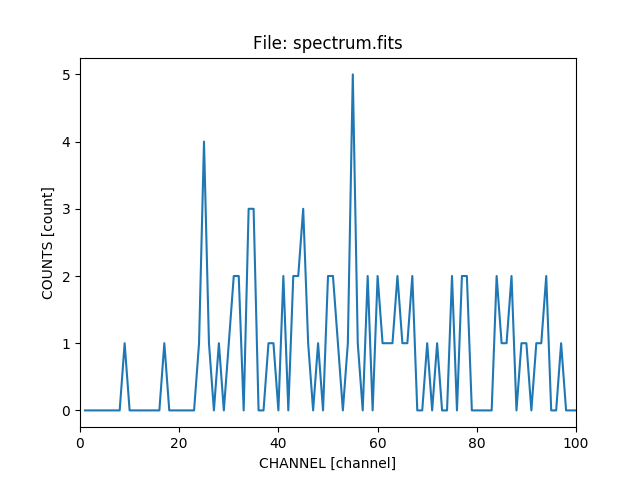

In [20]:

cat << EOM > p1.py
from pycrates import read_file
import matplotlib.pyplot as plt

tab = read_file("spectrum.fits")
xcol = tab.get_column("channel")
ycol = tab.get_column("counts")

def mklabel(col):
    lab = col.name
    if hasattr(col, "unit") and len(col.unit)>0:
        lab = lab + ' [{}]'.format(col.unit)
    return(lab)

xlab=mklabel(xcol)
ylab=mklabel(ycol)

plt.plot(xcol.values, ycol.values)
plt.xlim(0, 100)
plt.xlabel(xlab)
plt.ylabel(ylab)
plt.title("File: spectrum.fits")
plt.savefig("plot1.png")
EOM

python p1.py

display < plot1.png

### Multiple, type II

In [21]:
dmextract "${evt}[sky=region(s3_src.fits[component=igrid(1:15:1)])][bin pi=::1]" \
      multi_spectra_phaII.fits op=pha2 clob+


In [22]:
dmlist multi_spectra_phaII.fits blocks

 
--------------------------------------------------------------------------------
Dataset: multi_spectra_phaII.fits
--------------------------------------------------------------------------------
 
     Block Name                          Type         Dimensions
--------------------------------------------------------------------------------
Block    1: PRIMARY                        Null        
Block    2: SPECTRUM                       Table         7 cols x 15       rows
Block    3: GTI7                           Table         2 cols x 1        rows
Block    4: GTI5                           Table         2 cols x 1        rows
Block    5: GTI2                           Table         2 cols x 7        rows
Block    6: GTI3                           Table         2 cols x 7        rows
Block    7: GTI8                           Table         2 cols x 4        rows
Block    8: GTI6                           Table         2 cols x 4        rows


### Co-add spectra

In [23]:
dmcopy "s3_src.fits[#row=1:2,6:]" s3_nocore_src.fits cl+

In [24]:
dmextract "${evt}[sky=region(s3_nocore_src.fits)][bin pi=::1]" \
      spectrum_faint.fits cl+

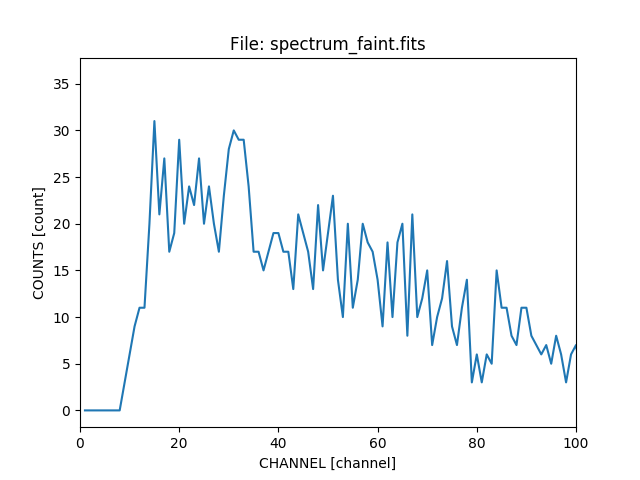

In [25]:

cat << EOM > p2.py
from pycrates import read_file
import matplotlib.pyplot as plt

tab = read_file("spectrum_faint.fits")
xcol = tab.get_column("channel")
ycol = tab.get_column("counts")

def mklabel(col):
    lab = col.name
    if hasattr(col, "unit") and len(col.unit)>0:
        lab = lab + ' [{}]'.format(col.unit)
    return(lab)

xlab=mklabel(xcol)
ylab=mklabel(ycol)

plt.plot(xcol.values, ycol.values)
plt.xlim(0,100)
plt.xlabel(xlab)
plt.ylabel(ylab)
plt.title("File: spectrum_faint.fits")
plt.savefig("plot2.png")
EOM

python p2.py

display < plot2.png

## Remove pt srcs

In [26]:
dmcopy "s3_src.fits[#row=1:2,6:15]" s3_holes_src.fits cl+

In [27]:
dmcopy "${evt}[exclude sky=region(s3_holes_src.fits)]" s3_holes_evt2.fits cl+

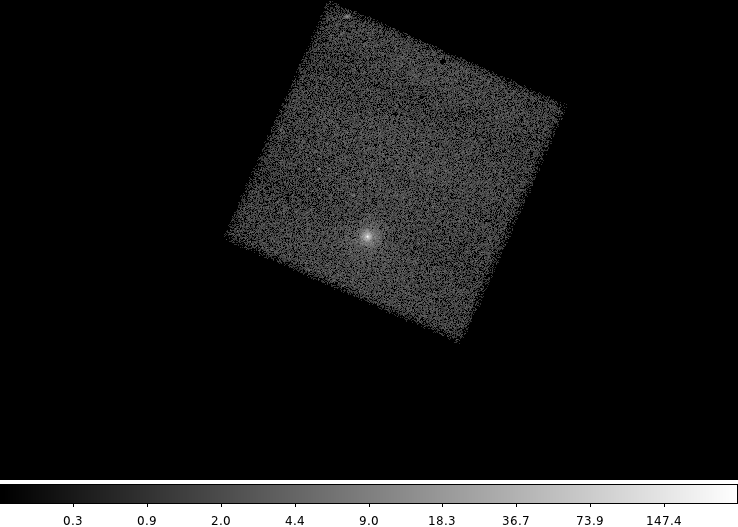

In [28]:
ds9 s3_holes_evt2.fits"[events,ccd_id=7]" -log -bin factor 4 -saveimage png ds9_3.png -quit
display < ds9_3.png

## As catalog


In [29]:
curl -O https://cxc.cfa.harvard.edu/ciao/threads/detect_output/src2tsv

In [30]:
python src2tsv s3_expmap_src.fits s3_src.tsv

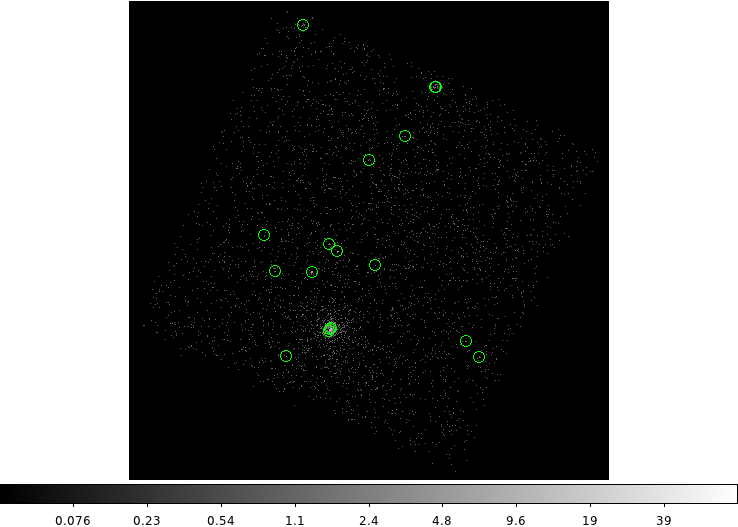

In [31]:
ds9 s3_broad_thresh.img -log -zoom to fit -catalog import tsv s3_src.tsv -saveimage png ds9_4.png -quit
display < ds9_4.png

### Cross match with 2MASS
    It's too hard to do the cross match stuff via notebook.  But one could it via xpa commands if you really wanted too.

# Cleanup

In [32]:
/bin/rm -rf 1522 578
/bin/rm -f bin*.img bin*.expmap 
/bin/rm -f s3*img s3*expmap
